In [46]:
import sqlite3

def update_experiment_view(db_path='../cem_results.db'):
    """
    Drops the existing experiment_summary view and recreates it 
    with the updated metrics schema including the testset column.
    """
    # Define the SQL script
    sql_script = """
    DROP VIEW IF EXISTS experiment_summary;

    CREATE VIEW experiment_summary AS
    SELECT 
        r.dataset,
        r.entity, 
        r.model_type,
        r.train_size, 
        r.seed, 
        r.lm,
        m.pollution, 
        m.iteration, 
        m.testset,
        m.f1_score,
        m.precision,
        m.recall,
        m.is_final,
        r.run_id,
        r.timestamp
    FROM metrics m
    JOIN runs r ON m.run_id = r.run_id;
    """

    try:
        # Establish connection
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Execute the script (handles multiple statements)
        cursor.executescript(sql_script)
        
        conn.commit()
        print("View 'experiment_summary' has been updated successfully.")
        
    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
        
    finally:
        if conn:
            conn.close()

# Run the update


In [47]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()
i = 8 # Set your desired number of recent runs here

try:
    # 2. Query the last 'i' run_ids from the "runs" table
    # We order by timestamp to ensure we get the truly most recent runs
    id_query = f"""SELECT r.run_id FROM runs r
    WHERE EXISTS (
    SELECT 1 FROM metrics m 
    WHERE m.run_id = r.run_id
    AND m.is_final = 1 
    AND m.testset = 'conv'
    )
    ORDER BY r.timestamp DESC LIMIT {i}"""
    last_run_ids = pd.read_sql_query(id_query, conn)['run_id'].tolist()
    
    if not last_run_ids:
        print("No runs found in the database.")
    else:
        print(last_run_ids)
        # 3. Query experiment_summary for these IDs where is_final=1
        # Using placeholders to prevent SQL injection and handle the list safely
        placeholders = ', '.join(['?'] * len(last_run_ids))
        summary_query = f"""
            SELECT * FROM experiment_summary 
            WHERE run_id IN ({placeholders}) 
            AND is_final = 1 AND testset = 'conv' AND dataset = 'imdb' ORDER BY entity, train_size, pollution
        """
        
        # Execute and load into DataFrame
        df_results = pd.read_sql_query(summary_query, conn, params=last_run_ids)
        
        print(f"Successfully retrieved data for {len(last_run_ids)} runs.")
        display(df_results)

        display(df_results.info())

finally:
    conn.close()

View 'experiment_summary' has been updated successfully.
['9763584_104055_name', '9763584_102923_movie', '9763556_3_102232_name', '9763559_2_101556_name', '9763557_0_101556_name', '9763556_3_101113_movie', '9763557_0_100856_movie', '9763559_2_100856_movie']
Successfully retrieved data for 8 runs.


,dataset,entity,model_type,train_size,seed,lm,pollution,iteration,testset,f1_score,precision,recall,is_final,run_id,timestamp
0,imdb,movie,1,0.125,42,roberta,high,2,conv,0.163,0.558,0.095,1,9763559_2_100856_movie,2026-04-16 10:08:56
1,imdb,movie,1,0.125,42,roberta,source,2,conv,0.999,0.999,0.999,1,9763557_0_100856_movie,2026-04-16 10:08:56
2,imdb,movie,1,1.000,42,roberta,high,3,conv,0.910,0.945,0.878,1,9763556_3_101113_movie,2026-04-16 10:11:13
3,imdb,movie,1,1.000,0,roberta,source,2,conv,0.999,0.999,1.000,1,9763584_102923_movie,2026-04-16 10:29:23
4,imdb,name,1,0.125,42,roberta,high,2,conv,0.810,0.792,0.829,1,9763559_2_101556_name,2026-04-16 10:15:56
5,imdb,name,1,0.125,42,roberta,source,2,conv,0.997,0.997,0.997,1,9763557_0_101556_name,2026-04-16 10:15:56
6,imdb,name,1,1.000,42,roberta,high,3,conv,0.971,0.973,0.970,1,9763556_3_102232_name,2026-04-16 10:22:32
7,imdb,name,1,1.000,0,roberta,source,2,conv,0.999,0.997,1.000,1,9763584_104055_name,2026-04-16 10:40:55


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dataset     8 non-null      str    
 1   entity      8 non-null      str    
 2   model_type  8 non-null      str    
 3   train_size  8 non-null      float64
 4   seed        8 non-null      int64  
 5   lm          8 non-null      str    
 6   pollution   8 non-null      str    
 7   iteration   8 non-null      int64  
 8   testset     8 non-null      str    
 9   f1_score    8 non-null      float64
 10  precision   8 non-null      float64
 11  recall      8 non-null      float64
 12  is_final    8 non-null      int64  
 13  run_id      8 non-null      str    
 14  timestamp   8 non-null      str    
dtypes: float64(4), int64(3), str(8)
memory usage: 1.6 KB


None

In [48]:
# Assuming df_results is your existing DataFrame
entities = df_results['entity'].unique()

for ent in entities:
    # Filter for the specific entity (movie/name)
    sub = df_results[df_results['entity'] == ent]
    
    # Helper to safely retrieve f1_score based on conditions
    def get_f1(size, poll):
        row = sub[(sub['train_size'] == size) & (sub['pollution'] == poll)]
        if not row.empty:
            return f"{row.iloc[0]['f1_score']:.3f}"
        return "0.000"

    # Extract the four specific scores requested
    f1_1_src   = get_f1(1.0, 'source')
    f1_1_high  = get_f1(1.0, 'high')
    f1_0125_src = get_f1(0.125, 'source')
    f1_0125_high = get_f1(0.125, 'high')

    # Construct and print the formatted LaTeX string
    latex_row = (
        f"{ent.capitalize()}  & TODO & {f1_1_src} & TODO & "
        f"{f1_1_high} & TODO & {f1_0125_src} & TODO & {f1_0125_high} \\\\"
    )
    
    print(latex_row)

Movie  & TODO & 0.999 & TODO & 0.910 & TODO & 0.999 & TODO & 0.163 \\
Name  & TODO & 0.999 & TODO & 0.971 & TODO & 0.997 & TODO & 0.810 \\


/var/folders/05/m7p6wsw10_qfvbrgqsl0m2p40000gn/T/ipykernel_73204/1706576516.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


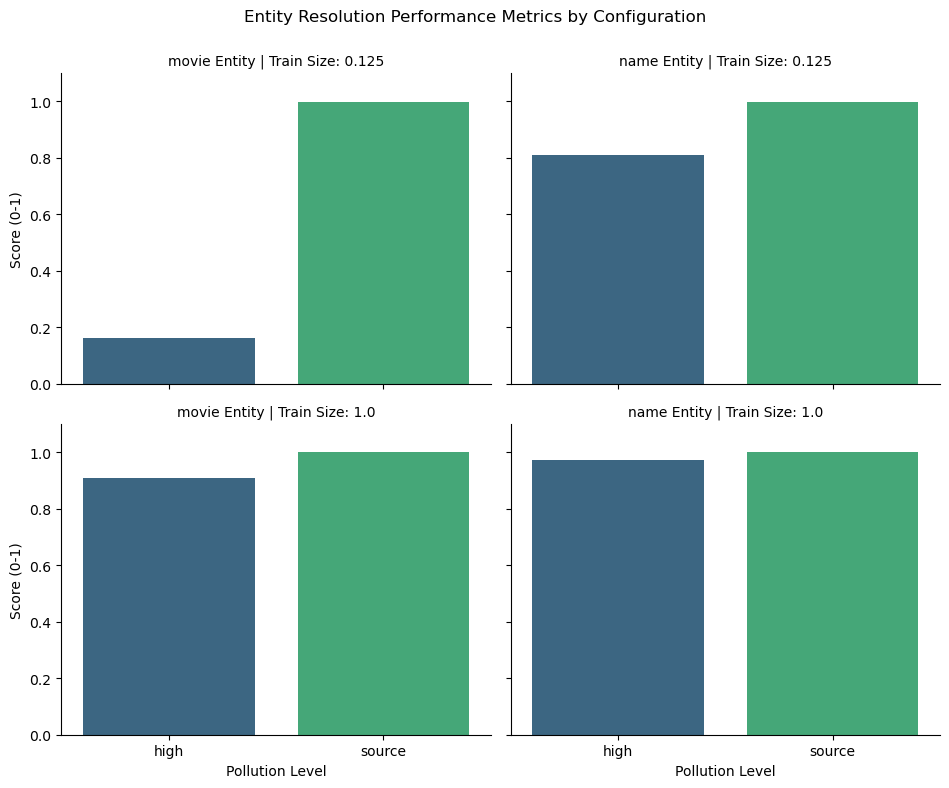

In [49]:

import seaborn as sns
import matplotlib.pyplot as plt

# 2. Reshape the dataframe to "Long Format" for easier plotting
# This combines precision, recall, and f1_score into a single 'Metric' column
# 3. Create the Visualization
# We create a column for 'entity' and rows for 'train_size'
# The x-axis shows the 'pollution' type, and 'Metric' distinguishes the bars
g = sns.catplot(
    data=df_results, 
    kind="bar",
    x="pollution", 
    y="f1_score", 
    # hue="f1_score",
    col="entity", 
    row="train_size",
    palette="viridis",
    height=4, 
    aspect=1.2
)

# 4. Refine the layout
g.set_axis_labels("Pollution Level", "Score (0-1)")
g.set_titles("{col_name} Entity | Train Size: {row_name}")
g.set(ylim=(0, 1.1)) # Metrics are between 0 and 1
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Entity Resolution Performance Metrics by Configuration')

plt.show()

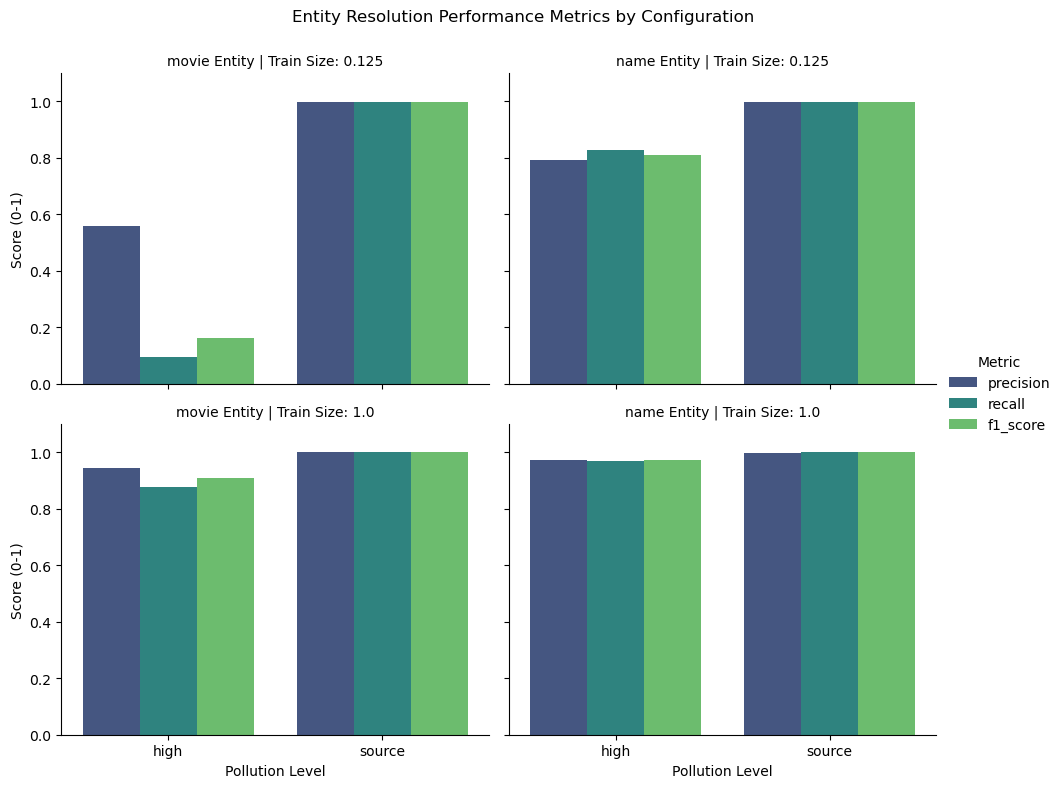

In [50]:

import seaborn as sns
import matplotlib.pyplot as plt

# 2. Reshape the dataframe to "Long Format" for easier plotting
# This combines precision, recall, and f1_score into a single 'Metric' column
df_melted = df_results.melt(
    id_vars=['entity', 'train_size', 'pollution'], 
    value_vars=['precision', 'recall', 'f1_score'],
    var_name='Metric', 
    value_name='Score'
)

# 3. Create the Visualization
# We create a column for 'entity' and rows for 'train_size'
# The x-axis shows the 'pollution' type, and 'Metric' distinguishes the bars
g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="pollution", 
    y="Score", 
    hue="Metric",
    col="entity", 
    row="train_size",
    palette="viridis",
    height=4, 
    aspect=1.2
)

# 4. Refine the layout
g.set_axis_labels("Pollution Level", "Score (0-1)")
g.set_titles("{col_name} Entity | Train Size: {row_name}")
g.set(ylim=(0, 1.1)) # Metrics are between 0 and 1
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Entity Resolution Performance Metrics by Configuration')

plt.show()

In [56]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()


try:

    summary_query = f"""
        SELECT * FROM experiment_summary WHERE testset = 'conv' AND entity = 'movie' ORDER BY "timestamp"  desc LIMIT 20
    """
    
    # Execute and load into DataFrame
    df_results = pd.read_sql_query(summary_query, conn)
    display(df_results)

finally:
    conn.close()


results_filtered = df_results.drop(columns=["dataset", "model_type", "lm", "testset", "is_final", "run_id", "timestamp"])
print(results_filtered.to_csv())

View 'experiment_summary' has been updated successfully.


,dataset,entity,model_type,train_size,seed,lm,pollution,iteration,testset,f1_score,precision,recall,is_final,run_id,timestamp
0,imdb,movie,1,1.000,0,roberta,source,0,conv,1.000,1.000,1.000,0,9763584_102923_movie,2026-04-16 10:29:23
1,imdb,movie,1,1.000,0,roberta,source,1,conv,0.999,0.999,1.000,0,9763584_102923_movie,2026-04-16 10:29:23
2,imdb,movie,1,1.000,0,roberta,source,2,conv,0.999,0.999,1.000,1,9763584_102923_movie,2026-04-16 10:29:23
3,imdb,movie,1,1.000,42,roberta,high,0,conv,0.868,0.969,0.786,0,9763556_3_101113_movie,2026-04-16 10:11:13
4,imdb,movie,1,1.000,42,roberta,high,1,conv,0.906,0.945,0.871,0,9763556_3_101113_movie,2026-04-16 10:11:13
5,imdb,movie,1,1.000,42,roberta,high,2,conv,0.907,0.945,0.872,0,9763556_3_101113_movie,2026-04-16 10:11:13
6,imdb,movie,1,1.000,42,roberta,high,3,conv,0.910,0.945,0.878,1,9763556_3_101113_movie,2026-04-16 10:11:13
7,imdb,movie,1,0.125,42,roberta,high,0,conv,0.151,0.607,0.086,0,9763559_2_100856_movie,2026-04-16 10:08:56
8,imdb,movie,1,0.125,42,roberta,source,0,conv,0.998,0.997,0.999,0,9763557_0_100856_movie,2026-04-16 10:08:56
9,imdb,movie,1,0.125,42,roberta,high,1,conv,0.163,0.558,0.095,0,9763559_2_100856_movie,2026-04-16 10:08:56


,entity,train_size,seed,pollution,iteration,f1_score,precision,recall
0,movie,1.0,0,source,0,1.0,1.0,1.0
1,movie,1.0,0,source,1,0.999,0.999,1.0
2,movie,1.0,0,source,2,0.999,0.999,1.0
3,movie,1.0,42,high,0,0.868,0.969,0.786
4,movie,1.0,42,high,1,0.906,0.945,0.871
5,movie,1.0,42,high,2,0.907,0.945,0.872
6,movie,1.0,42,high,3,0.91,0.945,0.878
7,movie,0.125,42,high,0,0.151,0.607,0.086
8,movie,0.125,42,source,0,0.998,0.997,0.999
9,movie,0.125,42,high,1,0.163,0.558,0.095
10,movie,0.125,42,source,1,0.999,0.999,0.999
11,movie,0.125,42,high,2,0.163,0.558,0.095
12,movie,0.125,42,source,2,0.999,0.999,0.999
13,movie,1.0,0,source,0,0.4,0.25,1.0
14,movie,1.0,0,source,1,0.4,0.25,1.0
15,movie,1.0,0,source,0,0.4,0.25,1.0
16,movie,1.0,0,source,1,0.4,0.25,1.0
17,movie,1.0,0,source,0,0.62,0.452,0.991
18,movie,1.0,0,source,1,0.621,0.452,0.992
19,movie,1.0,0,source,2,0.622,0.453,0.995



In [53]:


import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()
i = 8 # Set your desired number of recent runs here

try:

    print(last_run_ids)

    summary_query = f"""
        SELECT * FROM experiment_summary WHERE model_type = 'baseline' ORDER BY "timestamp"  desc LIMIT 20
    """
    
    # Execute and load into DataFrame
    df_baseline = pd.read_sql_query(summary_query, conn)
    
    print(f"Successfully retrieved data for {len(df_results)} runs.")
    baseline_filtered = df_baseline.drop(columns=["dataset", "lm", "testset", "is_final", "run_id", "timestamp"])
    display(baseline_filtered)

finally:
    conn.close()

# print(df_baseline.to_csv())

View 'experiment_summary' has been updated successfully.
['9763584_104055_name', '9763584_102923_movie', '9763556_3_102232_name', '9763559_2_101556_name', '9763557_0_101556_name', '9763556_3_101113_movie', '9763557_0_100856_movie', '9763559_2_100856_movie']
Successfully retrieved data for 20 runs.


,entity,model_type,train_size,seed,pollution,iteration,f1_score,precision,recall
0,name,baseline,1.000,42,high,0,0.918,0.970,0.872
1,name,baseline,1.000,42,source,0,1.000,1.000,1.000
2,name,baseline,1.000,42,source,1,1.000,1.000,1.000
3,name,baseline,1.000,42,high,1,0.918,0.970,0.872
4,name,baseline,1.000,0,source,0,1.000,1.000,1.000
5,name,baseline,1.000,0,source,1,1.000,1.000,1.000
6,name,baseline,0.125,42,source,0,0.834,0.762,0.921
7,name,baseline,0.125,42,high,0,0.590,0.510,0.701
8,name,baseline,0.125,42,high,1,0.590,0.510,0.701
9,name,baseline,0.125,42,source,1,0.834,0.762,0.921


In [55]:
target_entity = "movie"
target_size = 1.0
target_seed = 42
target_pollution = "high"

# Filter the dataframe
mask = (
    # (results_filtered["entity"] == target_entity) &
    (results_filtered["train_size"] == target_size) &
    (results_filtered["seed"] == target_seed) &
    (results_filtered["pollution"] == target_pollution)
)

display(results_filtered[mask])

# Filter the dataframe
mask = (
    # (results_filtered["entity"] == target_entity) &
    (baseline_filtered["train_size"] == target_size) &
    (baseline_filtered["seed"] == target_seed) &
    (baseline_filtered["pollution"] == target_pollution)
)

display(baseline_filtered[mask])



import pandas as pd

# Define the columns to match on
match_cols = ["train_size", "seed", "pollution", "entity"]

# Perform an inner join to align the rows
df_comparison = pd.merge(
    df_results, 
    df_baseline, 
    on=match_cols, 
    suffixes=('_res', '_base')
)

display(df_comparison)
# Now you can calculate differences, for example:
df_comparison['score_diff'] = df_comparison['f1_score_res'] - df_comparison['f1_score_base']
display(df_comparison)

,entity,train_size,seed,pollution,iteration,f1_score,precision,recall
6,name,1.0,42,high,0,0.892,0.922,0.864
7,name,1.0,42,high,1,0.971,0.973,0.970
8,name,1.0,42,high,2,0.973,0.970,0.976
9,name,1.0,42,high,3,0.971,0.973,0.970
16,movie,1.0,42,high,0,0.868,0.969,0.786
17,movie,1.0,42,high,1,0.906,0.945,0.871
18,movie,1.0,42,high,2,0.907,0.945,0.872
19,movie,1.0,42,high,3,0.910,0.945,0.878


,entity,model_type,train_size,seed,pollution,iteration,f1_score,precision,recall
0,name,baseline,1.0,42,high,0,0.918,0.970,0.872
3,name,baseline,1.0,42,high,1,0.918,0.970,0.872
12,movie,baseline,1.0,42,high,0,0.828,0.945,0.738
15,movie,baseline,1.0,42,high,1,0.828,0.945,0.738


,dataset_res,entity,model_type_res,train_size,seed,lm_res,pollution,iteration_res,testset_res,f1_score_res,...,model_type_base,lm_base,iteration_base,testset_base,f1_score_base,precision_base,recall_base,is_final_base,run_id_base,timestamp_base
0,imdb,name,1,1.000,0,roberta,source,0,conv,0.999,...,baseline,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
1,imdb,name,1,1.000,0,roberta,source,0,conv,0.999,...,baseline,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
2,imdb,name,1,1.000,0,roberta,source,1,conv,0.999,...,baseline,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
3,imdb,name,1,1.000,0,roberta,source,1,conv,0.999,...,baseline,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
4,imdb,name,1,1.000,0,roberta,source,2,conv,0.999,...,baseline,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
5,imdb,name,1,1.000,0,roberta,source,2,conv,0.999,...,baseline,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38
6,imdb,movie,1,1.000,0,roberta,source,0,conv,1.000,...,baseline,roberta,0,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48
7,imdb,movie,1,1.000,0,roberta,source,0,conv,1.000,...,baseline,roberta,1,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48
8,imdb,movie,1,1.000,0,roberta,source,1,conv,0.999,...,baseline,roberta,0,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48
9,imdb,movie,1,1.000,0,roberta,source,1,conv,0.999,...,baseline,roberta,1,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48


,dataset_res,entity,model_type_res,train_size,seed,lm_res,pollution,iteration_res,testset_res,f1_score_res,...,lm_base,iteration_base,testset_base,f1_score_base,precision_base,recall_base,is_final_base,run_id_base,timestamp_base,score_diff
0,imdb,name,1,1.000,0,roberta,source,0,conv,0.999,...,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
1,imdb,name,1,1.000,0,roberta,source,0,conv,0.999,...,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
2,imdb,name,1,1.000,0,roberta,source,1,conv,0.999,...,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
3,imdb,name,1,1.000,0,roberta,source,1,conv,0.999,...,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
4,imdb,name,1,1.000,0,roberta,source,2,conv,0.999,...,roberta,0,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
5,imdb,name,1,1.000,0,roberta,source,2,conv,0.999,...,roberta,1,test,1.000,1.000,1.000,1,9763647_110838_name,2026-04-16 11:08:38,-0.001
6,imdb,movie,1,1.000,0,roberta,source,0,conv,1.000,...,roberta,0,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48,0.001
7,imdb,movie,1,1.000,0,roberta,source,0,conv,1.000,...,roberta,1,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48,0.001
8,imdb,movie,1,1.000,0,roberta,source,1,conv,0.999,...,roberta,0,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48,0.000
9,imdb,movie,1,1.000,0,roberta,source,1,conv,0.999,...,roberta,1,test,0.999,0.998,1.000,1,9763647_105948_movie,2026-04-16 10:59:48,0.000
